# 04. A Kuramoto model of cicada chorus synchronisation

A cicada chorus starts as scattered calls and somehow ends up locked into a
common pulse. No conductor, no signal to follow, just a field of insects falling
into time with each other. That is exactly what the Kuramoto model captures: `N`
phase oscillators, each with its own natural frequency, pulled towards their
neighbours by a sine coupling,

$$ \frac{d\theta_i}{dt} = \omega_i + \frac{K}{N} \sum_j \sin(\theta_j - \theta_i). $$

Whether the population locks is read from the complex order parameter

$$ r\, e^{i\psi} = \frac{1}{N} \sum_j e^{i\theta_j}, $$

whose magnitude `|r|` runs from 0 for a scattered population to 1 for perfect
synchrony. This notebook shows the chorus synchronising, the coupling threshold
that decides whether it does at all, and, when a field recording is supplied,
the dominant call frequency in the audio.

The simulation and the coupling sweep run in `scripts/run_kuramoto.py` and are
read back here from `artifacts/`. This notebook loads them and draws the
result.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from nldynamics.kuramoto import audio_spectrum
from nldynamics.plotting import palette, setup_style


def project_root() -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "nldynamics").exists():
            return parent
    return Path.cwd()


setup_style()
ROOT = project_root()
data = np.load(ROOT / "artifacts" / "kuramoto.npz")
times = data["times"]
phases = data["phases"]
coherence, mean_phase = data["coherence"], data["mean_phase"]
coupling = float(data["coupling"])

## Synchronisation emerging

Fifty oscillators stand in for fifty callers, their natural frequencies drawn
around a common mean with a modest spread, so left alone they would drift apart.
Set the coupling above the critical value and the population locks together
instead: the order parameter starts near the level expected from a random
scatter of fifty oscillators and climbs towards one as they pull into time. The
committed README figure is this same curve.

50 oscillators, 3000 steps, coupling K = 1.5
coherence: 0.168 at the start, 0.967 at the end


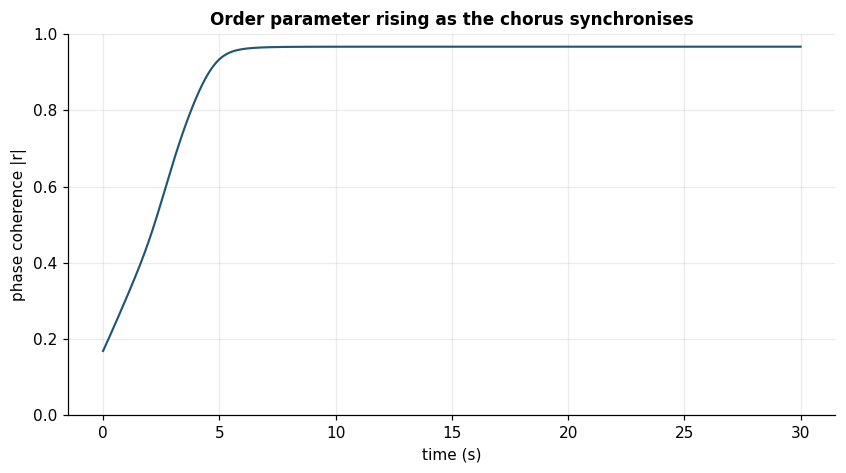

In [2]:
print(f"{phases.shape[1]} oscillators, {phases.shape[0]} steps, coupling K = {coupling:g}")
print(f"coherence: {coherence[0]:.3f} at the start, {coherence[-200:].mean():.3f} at the end")

fig, ax = plt.subplots()
ax.plot(times, coherence, color=palette("orbit"), lw=1.4)
ax.set_ylim(0, 1)
ax.set_xlabel("time (s)")
ax.set_ylabel("phase coherence |r|")
ax.set_title("Order parameter rising as the chorus synchronises")
plt.show()

Another view plots each oscillator's phase against time as it's pulled into the
common rhythm. The bundle of trajectories, initially spread across the circle,
draws together into a single advancing band.

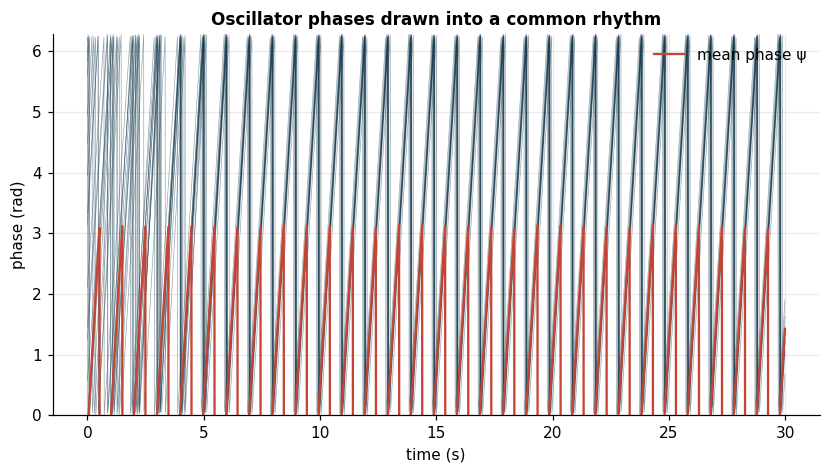

In [3]:
fig, ax = plt.subplots()
ax.plot(times, phases[:, ::4], color=palette("attractor"), lw=0.4, alpha=0.5)
ax.plot(times, mean_phase, color=palette("chaotic"), lw=1.5, label="mean phase ψ")
ax.set_ylim(0, 2 * np.pi)
ax.set_xlabel("time (s)")
ax.set_ylabel("phase (rad)")
ax.set_title("Oscillator phases drawn into a common rhythm")
ax.legend(loc="upper right")
plt.show()

## The coupling threshold

What decides whether the chorus locks? The Kuramoto transition is sharp: below a
critical coupling set by the spread of natural frequencies the population stays
incoherent, and above it a synchronised cluster forms. The sweep records the
final coherence of an otherwise identical run at each coupling strength, so only
the coupling differs along the curve.

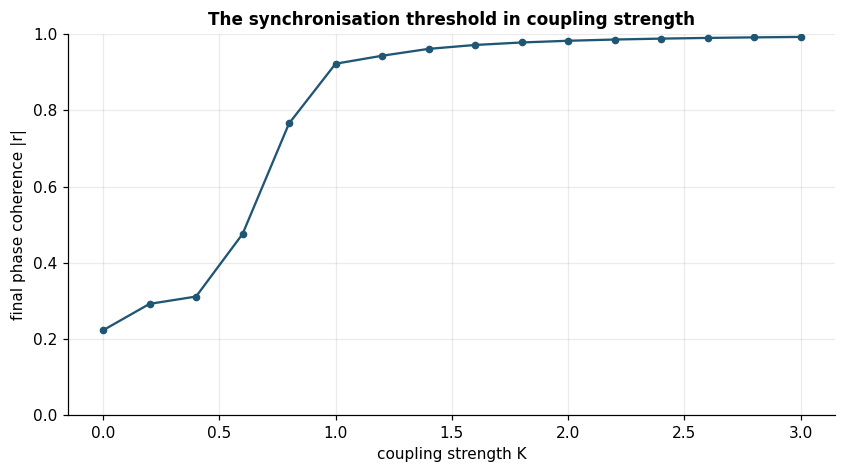

In [4]:
fig, ax = plt.subplots()
ax.plot(
    data["sweep_couplings"],
    data["sweep_final_coherence"],
    color=palette("orbit"),
    marker="o",
    ms=4,
)
ax.set_ylim(0, 1)
ax.set_xlabel("coupling strength K")
ax.set_ylabel("final phase coherence |r|")
ax.set_title("The synchronisation threshold in coupling strength")
plt.show()

The curve is flat and low at weak coupling, then rises through a knee and
saturates near one: the Kuramoto transition. The knee marks the critical
coupling, above which the pull towards the mean phase overcomes the spread in
natural frequencies.

## The recorded chorus

The model can be tied back to a real recording. The dominant frequency of a
field capture of a cicada chorus is the rhythm the population has synchronised
onto, the audio counterpart of the model's natural frequency. That capture is
large and not committed (see `data/README.md`), so this section detects its
absence and reports it rather than failing.

sample rate 48000 Hz, duration 79.0 s
dominant frequency 7369 Hz


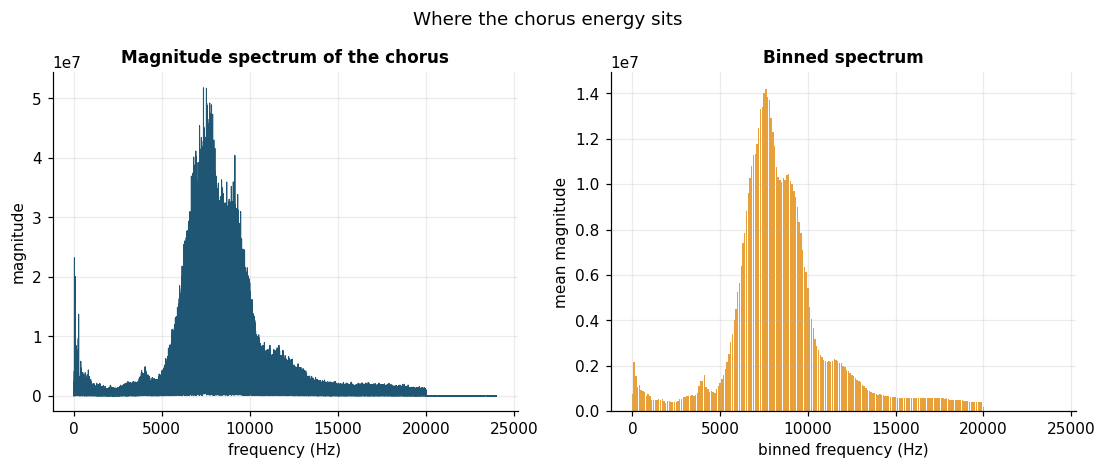

In [5]:
audio_rel = Path("data") / "raw" / "cicada_kuramoto.wav"
audio_path = ROOT / audio_rel
if audio_path.exists():
    spectrum = audio_spectrum(audio_path, bin_width=100.0)
    print(f"sample rate {spectrum.sample_rate} Hz, duration {spectrum.duration:.1f} s")
    print(f"dominant frequency {spectrum.dominant_frequency:.0f} Hz")

    fig, (ax_full, ax_bins) = plt.subplots(1, 2, figsize=(12, 4))
    ax_full.plot(spectrum.frequency, spectrum.magnitude, color=palette("orbit"), lw=0.7)
    ax_full.set_xlabel("frequency (Hz)")
    ax_full.set_ylabel("magnitude")
    ax_full.set_title("Magnitude spectrum of the chorus")

    ax_bins.bar(
        spectrum.bin_frequency,
        spectrum.bin_magnitude,
        width=80.0,
        color=palette("highlight"),
    )
    ax_bins.set_xlabel("binned frequency (Hz)")
    ax_bins.set_ylabel("mean magnitude")
    ax_bins.set_title("Binned spectrum")
    fig.suptitle("Where the chorus energy sits", y=1.02)
    plt.show()
else:
    print(
        f"recording not found at {audio_rel}; skipping the spectrum.\n"
        "Supply a mono WAV as described in data/README.md to run this section."
    )

When a recording is present, the magnitude spectrum concentrates around the
call frequency and the binned view summarises where the energy sits. That peak
is the chorus rhythm the Kuramoto population synchronises onto.

## Summary

- A Kuramoto population of fifty oscillators with spread natural frequencies and
  a coupling above the critical value synchronises: the order parameter climbs
  from a scattered start to close to one.
- The phase trajectories show the same thing directly, drawing together into a
  single advancing band led by the mean phase.
- Sweeping the coupling traces the Kuramoto transition: flat and incoherent
  below the critical strength, saturating near one above it.
- The optional audio section reads a chorus recording and reports its dominant
  frequency, the empirical counterpart of the model's natural frequency, and
  degrades gracefully when the recording is absent.